AQI FORECASTING MODEL CODE

In [ ]:
# CELL 1 — Environment & imports (safe)
import warnings, os, random, time
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib, json

# reproducibility
import tensorflow as tf
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Try optional pmdarima (do NOT force-install here)
try:
    import pmdarima as pm
    print("pmdarima available:", pm.__version__)
except Exception as e:
    pm = None
    print("pmdarima not available (will use statsmodels). Error:", str(e))

# Statsmodels always available in Colab
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# shap optional; we'll fallback to permutation importance if unavailable
try:
    import shap
except Exception:
    shap = None

print("TensorFlow:", tf.__version__, "NumPy:", np.__version__)


pmdarima not available (will use statsmodels). Error: No module named 'pmdarima'
TensorFlow: 2.19.0 NumPy: 2.0.2


### ✔️ Explanation: Importing Libraries & Setting Up the Environment  
This cell imports all required Python libraries such as NumPy, Pandas, TensorFlow, Scikit-Learn, and Statsmodels.  
It also sets random seeds to ensure **reproducibility**, meaning the model produces the same results each time it is run.

#### 🔍 Key Definitions  
- **Reproducibility:** Ability to get identical results every run by fixing random seeds.  
- **TensorFlow:** A deep learning library used to build neural networks like LSTM.  
- **NumPy/Pandas:** Libraries for numerical computation and data handling.

This setup ensures a stable and consistent environment for the entire project.


In [ ]:
 # CELL 2 — Robust dataset loader (canonical)
import os, pandas as pd

possible = [
    "./aqi_dataset.csv",
    "./data/aqi_dataset.csv",
    "/mnt/data/aqi_dataset.csv",
    "/content/aqi_dataset.csv",
    "aqi_dataset.csv"
]

csv_path = None
for p in possible:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    # try gdown (only if internet allowed and file id known)
    try:
        import gdown
        file_id = "1-JdY0p0PHt34VHlULz8RkR9B62k-Futb"  # change if you have a different id
        url = f"https://drive.google.com/uc?id={file_id}"
        csv_path = "./aqi_dataset.csv"
        print("Downloading dataset via gdown...")
        gdown.download(url, csv_path, quiet=False)
    except Exception as e:
        raise RuntimeError(
            "Dataset file not found locally and gdown failed. Upload your dataset into working dir "
            "(file named aqi_dataset.csv) or set the correct path/file-id."
        ) from e

# load with first column as index if that was the format; adjust index_col if needed
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
print("Reloaded df from:", csv_path, "shape:", df.shape)
display(df.head())


Downloading...
From: https://drive.google.com/uc?id=1-JdY0p0PHt34VHlULz8RkR9B62k-Futb
To: /content/aqi_dataset.csv
100%|██████████| 6.00M/6.00M [00:00<00:00, 202MB/s]


Reloaded df from: ./aqi_dataset.csv shape: (26280, 27)


,station_id,distance_km,lat,lon,PM2.5,PM10,NO2,SO2,CO,O3,...,CO_subindex,O3_subindex,AQI_CPCB,AQI_Category,PM2.5_subindex,PM10_subindex_subindex,NO2_subindex_subindex,SO2_subindex_subindex,CO_subindex_subindex,O3_subindex_subindex
Datetime,,,,,,,,,,,,,,,,,,,,,
01-01-2024 00:00,ST1,0.5,22.0,88.0,36.43,54.78,26.90,19.81,0.575,23.69,...,28.75,23.69,369.245562,Very Poor,60.174828,54.78,42.031250,30.953125,369.245562,23.69
01-01-2024 01:00,ST1,0.5,22.0,88.0,27.20,80.34,40.40,19.94,0.621,26.66,...,31.05,26.66,500.000000,Severe,45.333333,80.34,402.021044,31.156250,382.718935,26.66
01-01-2024 02:00,ST1,0.5,22.0,88.0,28.34,60.03,33.62,17.61,0.630,21.12,...,31.50,21.12,385.355030,Very Poor,47.233333,60.03,52.287821,27.515625,385.355030,21.12
01-01-2024 03:00,ST1,0.5,22.0,88.0,33.33,66.35,35.06,20.70,0.502,27.98,...,25.10,27.98,347.863905,Very Poor,54.936897,66.35,54.549359,32.343750,347.863905,27.98
01-01-2024 04:00,ST1,0.5,22.0,88.0,32.02,58.33,31.51,15.77,0.503,15.32,...,25.15,15.32,348.156805,Very Poor,52.723448,58.33,49.234375,24.640625,348.156805,15.32


### ✔️ Explanation: Dataset Loading & Datetime Processing  
This cell loads the AQI dataset. If it is not available locally, it downloads it automatically.  
The code also attempts to detect and convert timestamp columns into a proper **DatetimeIndex**.

#### 🔍 Key Definitions  
- **DatetimeIndex:** A special timestamp-based index used for time-series operations.  
- **Time-series data:** Data collected at regular time intervals (e.g., hourly AQI).

This step ensures the dataset is correctly structured for time-series modeling.


In [ ]:
# Normalize columns and ensure datetime index (paste into loader cell)
import pandas as pd, numpy as np
# canonicalize column names minimally
df.columns = [c.strip() for c in df.columns]

# Try to set datetime index
if not isinstance(df.index, pd.DatetimeIndex):
    # try common datetime column names
    for col in ['timestamp','date','datetime','time']:
        if col in df.columns:
            try:
                df.index = pd.to_datetime(df[col], errors='coerce')
                df = df.sort_index()
                print("Index set from column:", col)
                break
            except Exception:
                pass
    # fallback: try to parse index values
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index, errors='coerce')
            if df.index.isnull().any():
                raise ValueError("Index conversion produced NaT")
            df = df.sort_index()
            print("Index parsed from existing index.")
        except Exception:
            # As last resort create a synthetic datetime index (document this)
            df.index = pd.date_range(start="2020-01-01", periods=len(df), freq="H")
            print("Index was not datetime. Created synthetic hourly index.")


Index was not datetime. Created synthetic hourly index.


In [ ]:
# CELL 3 — Clear stale variables
for v in ['train_df','test_df','X_all','y_all','X_train','y_train','X_test','y_test']:
    if v in globals():
        del globals()[v]
print("Cleared old train/test variables.")


Cleared old train/test variables.


### ✔️ Explanation: Clearing Previous Variables  
This cell removes old variables such as previously created training/testing arrays.  
It ensures that older runs do not interfere with current execution.

Keeping a clean workspace avoids unexpected errors in later stages.


In [ ]:
# CELL 4 — Recompute found_cols & feature_col list
expected_pollutants = ['PM2.5','PM10','NO2','SO2','CO','O3','Temperature','Humidity','WindSpeed','AQI']
# If you have a precomputed found_cols variable earlier, it will be used instead
if 'found_cols' not in globals():
    found_cols = [c for c in df.columns if c in expected_pollutants]
    print("Auto-built found_cols from expected list:", found_cols)
else:
    print("Using existing found_cols variable.")

# target column name (adjust if different)
target_col = 'AQI'  # change if your notebook uses a different target
print("target_col:", target_col)

# Build feature_cols similarly to original logic
feature_cols = [c for c in df.columns if (c in found_cols) or ('_lag_' in c) or ('_roll_' in c) or c in ['month','hour']]
feature_cols = sorted(list(set(feature_cols)))
print("Feature cols count:", len(feature_cols))
print("Some feature columns:", feature_cols[:20])


Auto-built found_cols from expected list: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'WindSpeed', 'AQI']
target_col: AQI
Feature cols count: 10
Some feature columns: ['AQI', 'CO', 'Humidity', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'Temperature', 'WindSpeed']


### ✔️ Explanation: Pollutant Detection & Feature List Construction  
This cell automatically identifies pollutant columns such as PM2.5, PM10, NO₂, CO, SO₂, and O₃.  
It builds the `feature_cols` list that will be used as inputs for the model.

#### 🔍 Key Definitions  
- **Feature:** An input variable used for prediction.  
  Example: PM2.5 concentration, humidity, temperature.

Automatic detection makes the notebook adaptable to different datasets.


In [ ]:
# CELL 5 — (separator / notes)
# SAFE CELL: Detect pollutant columns, compute CPCB sub-indices robustly
# Paste & run this cell now (it is self-contained)
# ------------------------------
import numpy as np, pandas as pd, re, math
from collections.abc import Iterable

# quick guard
if 'df' not in globals():
    raise RuntimeError("DataFrame 'df' is not defined in this session. Run the cell that loads the CSV first.")

# CPCB breakpoints (same as earlier)
BREAKPOINTS = {
    'pm25': [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    'pm10': [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,10000,401,500)],
    'no2':  [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,10000,401,500)],
    'so2':  [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,100000,401,500)],
    'co':   [(0,1,0,50),(1.1,2,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,1000,401,500)],
    'o3':   [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(749,100000,401,500)]
}

def calc_sub_index(conc, bp):
    # conc should be numeric or nan
    try:
        conc = float(conc)
    except Exception:
        return np.nan
    for low, high, il, ih in bp:
        if low <= conc <= high:
            # avoid division by zero
            if high == low:
                return ih
            return ((ih - il) / (high - low)) * (conc - low) + il
    return 500.0

def safe_to_float(x):
    """Robust conversion of cell to float. Handles scalar, numeric strings, simple list-like strings, lists/tuples/ndarrays."""
    if x is None:
        return np.nan
    # Already numeric
    if isinstance(x, (int, float, np.floating, np.integer)) and not (isinstance(x, bool)):
        return float(x)
    # Iterable (list/tuple/ndarray) - try to find a numeric element
    if isinstance(x, Iterable) and not isinstance(x, (str, bytes)):
        for el in x:
            try:
                return float(el)
            except Exception:
                continue
        return np.nan
    # String - try direct float, else regex extract first number
    if isinstance(x, str):
        s = x.strip()
        try:
            return float(s)
        except:
            # find first number pattern
            m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
            if m:
                try:
                    return float(m.group(0))
                except:
                    return np.nan
            return np.nan
    # fallback
    try:
        return float(x)
    except:
        return np.nan

# Heuristic mapping for pollutant columns (left side: tokens we look for in colname -> canonical key)
pollutant_tokens = {
    'pm25': ['pm2.5','pm25','pm_25'],
    'pm10': ['pm10','pm_10'],
    'no2' : ['no2','nox','no_2'],
    'so2' : ['so2','so_2'],
    'co'  : ['co','co2?'],   # co might conflict with co2; we still include it
    'o3'  : ['o3','ozone','o_3']
}

# Discover columns that map to pollutants
found_cols = []    # will hold raw df column names that map to pollutants
col_to_pollutant = {}  # mapping raw_col -> canonical pollutant key (pm25, pm10, etc.)

for raw_col in df.columns:
    low = raw_col.lower().replace(" ", "").replace("_","")
    matched = False
    for key, toks in pollutant_tokens.items():
        for t in toks:
            if t.replace("_","") in low:
                # avoid matching 'co2' as 'co' incorrectly: require exact 'co' token in name if contains digit sequence?
                # simple guard: if token is 'co' then ensure column name not 'co2' literal
                if key == 'co' and ('co2' in low or 'co_2' in low):
                    continue
                found_cols.append(raw_col)
                col_to_pollutant[raw_col] = key
                matched = True
                break
        if matched: break

# remove duplicates keeping order
seen = set()
found_cols = [x for x in found_cols if not (x in seen or seen.add(x))]

if len(found_cols) == 0:
    print("No pollutant-like columns detected automatically. Columns available:\n", df.columns.tolist()[:40])
    raise RuntimeError("Please check CSV column names (expected PM2.5, PM10, NO2, SO2, CO, O3 in headers).")

print("Detected pollutant columns (raw names):", found_cols)
print("Column -> pollutant mapping:", col_to_pollutant)

# Compute subindices robustly (idempotent)
computed = []
problem_rows = {}
for raw_col in found_cols:
    pollutant_key = col_to_pollutant.get(raw_col)
    if pollutant_key not in BREAKPOINTS:
        print(f"Skipping column {raw_col}: no CPCB breakpoint defined for '{pollutant_key}'")
        continue
    sub_col = f"{raw_col}_subindex"
    # If already exists and seems numeric, skip recomputing
    if sub_col in df.columns and pd.api.types.is_numeric_dtype(df[sub_col]):
        print(f"Subindex column already exists and numeric: {sub_col} (skipping recompute)")
        computed.append(sub_col)
        continue

    vals = []
    bad_indices = []
    for idx, raw in df[raw_col].items():
        num = safe_to_float(raw)
        if math.isnan(num):
            bad_indices.append(idx)
            vals.append(np.nan)
        else:
            vals.append(calc_sub_index(num, BREAKPOINTS[pollutant_key]))
    # assign back as numeric series
    df[sub_col] = pd.Series(vals, index=df.index).astype(float)
    computed.append(sub_col)
    if bad_indices:
        problem_rows[raw_col] = bad_indices[:5]

print("Computed subindex columns:", computed)
if problem_rows:
    print("\nWarning: Some cells could not be parsed to numeric values (first few indices shown):")
    for c, idxs in problem_rows.items():
        print(" -", c, ":", idxs)
print("You can now inspect df[computed_subcols].head()")
display(df[[c for c in computed if c in df.columns]].head())


Detected pollutant columns (raw names): ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'PM10_subindex', 'NO2_subindex', 'SO2_subindex', 'CO_subindex', 'O3_subindex', 'PM2.5_subindex', 'PM10_subindex_subindex', 'NO2_subindex_subindex', 'SO2_subindex_subindex', 'CO_subindex_subindex', 'O3_subindex_subindex']
Column -> pollutant mapping: {'PM2.5': 'pm25', 'PM10': 'pm10', 'NO2': 'no2', 'SO2': 'so2', 'CO': 'co', 'O3': 'o3', 'PM10_subindex': 'pm10', 'NO2_subindex': 'no2', 'SO2_subindex': 'so2', 'CO_subindex': 'co', 'O3_subindex': 'o3', 'PM2.5_subindex': 'pm25', 'PM10_subindex_subindex': 'pm10', 'NO2_subindex_subindex': 'no2', 'SO2_subindex_subindex': 'so2', 'CO_subindex_subindex': 'co', 'O3_subindex_subindex': 'o3'}
Subindex column already exists and numeric: PM2.5_subindex (skipping recompute)
Subindex column already exists and numeric: PM10_subindex (skipping recompute)
Subindex column already exists and numeric: NO2_subindex (skipping recompute)
Subindex column already exists and numeric: SO

,PM2.5_subindex,PM10_subindex,NO2_subindex,SO2_subindex,CO_subindex,O3_subindex,PM10_subindex_subindex,NO2_subindex_subindex,SO2_subindex_subindex,CO_subindex_subindex,O3_subindex_subindex,PM2.5_subindex_subindex,PM10_subindex_subindex_subindex,NO2_subindex_subindex_subindex,SO2_subindex_subindex_subindex,CO_subindex_subindex_subindex,O3_subindex_subindex_subindex
2020-01-01 00:00:00,60.174828,54.78,33.6250,24.7625,28.75,23.69,54.78,42.031250,30.953125,369.245562,23.69,500.000000,54.78,52.295673,38.691406,435.350772,23.69
2020-01-01 01:00:00,45.333333,80.34,500.0000,24.9250,31.05,26.66,80.34,402.021044,31.156250,382.718935,26.66,75.218391,80.34,401.010531,38.945312,436.731726,26.66
2020-01-01 02:00:00,47.233333,60.03,42.0250,22.0125,31.50,21.12,60.03,52.287821,27.515625,385.355030,21.12,78.428736,60.03,65.182133,34.394531,437.001913,21.12
2020-01-01 03:00:00,54.936897,66.35,43.8250,25.8750,25.10,27.98,66.35,54.549359,32.343750,347.863905,27.98,91.445101,66.35,68.023554,40.429688,433.159257,27.98
2020-01-01 04:00:00,52.723448,58.33,39.3875,19.7125,25.15,15.32,58.33,49.234375,24.640625,348.156805,15.32,87.705137,58.33,61.345753,30.800781,433.189278,15.32


### ✔️ Explanation: AQI Sub-index Calculation (CPCB Standard)  
This cell converts raw pollutant concentrations into **sub-index values** using CPCB-defined AQI breakpoints.  
It also handles messy numeric formats safely and adds columns like `PM25_subindex`.

#### 🔍 Key Definitions  
- **CPCB:** Central Pollution Control Board (India).  
- **Sub-index:** AQI contribution of a single pollutant.  
- **AQI Breakpoints:** Thresholds that convert pollutant levels into AQI scores.

Sub-indices standardize pollutant impacts and are essential for AQI computation.


In [ ]:
# CELL 6 — Winsorize pollutant columns and impute small gaps
for c in found_cols:
    vals = pd.to_numeric(df[c], errors='coerce')
    lo = vals.quantile(0.001)
    hi = vals.quantile(0.999)
    df[c] = vals.clip(lower=lo, upper=hi)
    df[c] = df[c].interpolate(limit=6).fillna(method='bfill').fillna(method='ffill')
print("Winsorized + imputed pollutants.")


Winsorized + imputed pollutants.


### ✔️ Explanation: Winsorization & Missing Value Imputation  
This cell removes extreme values using **winsorization** and fills missing data using interpolation.  
Then it applies backward and forward filling to maintain continuous time-series data.

#### 🔍 Key Definitions  
- **Winsorization:** Clipping extreme values to reduce noise from sensor spikes.  
- **Imputation:** Filling missing values.  
- **Interpolation:** Estimating values between two known data points.

These steps stabilize the dataset and prepare it for accurate modeling.


In [ ]:
# Canonicalize pollutant names to predictable keys
rename_map = {}
for c in df.columns:
    normal = c.lower().replace('.','_').replace('-','_').replace(' ','')
    if normal in ('pm25','pm2_5','pm_2_5'):
        rename_map[c] = 'PM2.5'
    elif normal == 'pm10':
        rename_map[c] = 'PM10'
    elif normal == 'no2':
        rename_map[c] = 'NO2'
    elif normal == 'so2':
        rename_map[c] = 'SO2'
    elif normal == 'co':
        rename_map[c] = 'CO'
    elif normal in ('o3','o_3'):
        rename_map[c] = 'O3'
if rename_map:
    df = df.rename(columns=rename_map)
    print("Renamed columns:", rename_map)


Renamed columns: {'PM2.5': 'PM2.5', 'PM10': 'PM10', 'NO2': 'NO2', 'SO2': 'SO2', 'CO': 'CO', 'O3': 'O3'}


In [ ]:
# CELL 7 — Feature engineering and time index
possible_dt = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower() or 'datetime' in c.lower()]
dt_col = possible_dt[0] if possible_dt else df.columns[0]
df[dt_col] = pd.to_datetime(df[dt_col], errors='coerce')
df = df.dropna(subset=[dt_col]).sort_values(dt_col).set_index(dt_col)

target_col = 'AQI_CPCB'
# Create forward-safe lag & rolling features
def add_forward_safe_features(df, col, lags=[1,24], roll_windows=[24]):
    for l in lags:
        df[f"{col}_lag_{l}"] = df[col].shift(l)
    for w in roll_windows:
        # shift first to avoid using current+future values
        df[f"{col}_roll_{w}"] = df[col].shift(1).rolling(window=w, min_periods=1).mean()
    return df

for col in ['PM2.5','PM10','NO2','SO2','CO','O3']:
    if col in df.columns:
        df = add_forward_safe_features(df, col)



### ✔️ Explanation: Time-based Feature Engineering  
This cell ensures the dataset has a valid timestamp index.  
It generates **lag features** (previous-hour values) and **rolling averages** to capture temporal patterns.  
It also creates time-related features like hour-of-day and day-of-week.

#### 🔍 Key Definitions  
- **Lag Feature:** Previous value used to predict the next one (e.g., AQI one hour ago).  
- **Rolling Window:** Moving average over a fixed window size.  
- **Temporal Feature:** Time-based information such as hour or weekday.

These features help the model learn trends and seasonal behaviors in pollution.


In [ ]:
# CELL 8 — Guarded split/scale/sequence (robust Cell 6)
# safety guard inside Cell 8

if 'df' not in globals() or df.shape[0] == 0:
    print("df missing or empty – attempting reload.")
    from pathlib import Path
    import pandas as pd
    if Path("aqi_dataset.csv").exists():
        df = pd.read_csv("aqi_dataset.csv", index_col=0, parse_dates=True)
        print("Reloaded aqi_dataset.csv, shape:", df.shape)
    else:
        from google.colab import files
        print("Please upload your dataset (aqi_dataset.csv)")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname, index_col=0, parse_dates=True)
        print("Loaded uploaded file, shape:", df.shape)


import numpy as np
from sklearn.preprocessing import MinMaxScaler

# basic checks
print("df.shape before processing:", df.shape)
if df.shape[0] == 0:
    raise RuntimeError("Reload failed or df is empty. Re-run the reload step (Cell A).")

# confirm feature_cols presence, fallback if none found
found_feature_cols = [c for c in feature_cols if c in df.columns]
missing_feature_cols = [c for c in feature_cols if c not in df.columns]
if len(found_feature_cols) == 0:
    raise RuntimeError(f"No feature columns found in df. Missing examples: {missing_feature_cols[:10]}")

print(f"Found {len(found_feature_cols)} / {len(feature_cols)} feature columns in df. Missing (first 10): {missing_feature_cols[:10]}")

# Print NA counts for these columns + target
cols_to_check = found_feature_cols + ([target_col] if target_col in df.columns else [])
print("Missing counts for selected cols:")
print(df[cols_to_check].isna().sum().sort_values(ascending=False).head(20))

# If dropna would remove everything, attempt safe imputation (ffill -> bfill -> interpolate)
drop_candidate_count = df.dropna(subset=cols_to_check).shape[0]
print("Rows remaining if dropna applied:", drop_candidate_count)

if drop_candidate_count == 0:
    print("dropna would remove all rows. Applying safe imputation (ffill->bfill->interpolate).")
    df_imputed = df.copy()
    df_imputed[cols_to_check] = df_imputed[cols_to_check].ffill().bfill()
    try:
        df_imputed[cols_to_check] = df_imputed[cols_to_check].interpolate(method='time', limit_direction='both')
    except Exception:
        df_imputed[cols_to_check] = df_imputed[cols_to_check].interpolate(method='linear', limit_direction='both')
    post_imp_count = df_imputed.dropna(subset=cols_to_check).shape[0]
    print("Rows after imputation (non-null):", post_imp_count)
    if post_imp_count == 0:
        raise RuntimeError("Imputation didn't produce valid rows. Inspect dataset.")
    df = df_imputed
    print("Imputation applied. New df.shape:", df.shape)
else:
    df = df.dropna(subset=cols_to_check)
    print("Applied dropna; df.shape:", df.shape)

# Ensure datetime index and monotonic ordering
if not isinstance(df.index, pd.DatetimeIndex):
    try:
        df.index = pd.to_datetime(df.index)
        print("Converted index to DatetimeIndex.")
    except Exception:
        print("Warning: index could not be parsed to datetime. Splitting by position will be used if necessary.")

if not df.index.is_monotonic_increasing:
    df = df.sort_index()
    print("Sorted df by index to enforce monotonic order.")

# Sequence length (ensure it's defined)
SEQ_LEN = 24
if len(df) < SEQ_LEN + 2:
    raise RuntimeError(f"Not enough rows ({len(df)}) for SEQ_LEN={SEQ_LEN}. Use smaller SEQ_LEN or more data.")

# Time-based split using timestamp at the train cutoff (keeps duplicate timestamps together)
train_size = int(len(df) * 0.8)
pos_train_end = train_size - 1
train_cutoff = df.index[pos_train_end]

train_df = df.loc[df.index <= train_cutoff].copy()
test_df  = df.loc[df.index > train_cutoff].copy()

if test_df.shape[0] == 0:
    print("Time-based split produced empty test set; falling back to positional split.")
    train_df = df.iloc[:train_size].copy()
    test_df  = df.iloc[train_size:].copy()

print("After split -> train rows:", len(train_df), "test rows:", len(test_df))
if len(test_df) > 0:
    assert train_df.index.max() < test_df.index.min(), "Train/test overlap after split."

# Fit scalers on train only
scaler_X = MinMaxScaler().fit(train_df[found_feature_cols])
scaler_y = MinMaxScaler().fit(train_df[[target_col]])

# transform the full df (we will make sequences without leakage)
X_all = scaler_X.transform(df[found_feature_cols])
y_all = scaler_y.transform(df[[target_col]])

# Sequence maker (no-leak)
def make_sequences_no_leak(X_full, y_full, train_len, seq_len):
    X_train, y_train, X_test, y_test = [], [], [], []
    for i in range(0, train_len - seq_len):
        X_train.append(X_full[i:i+seq_len]); y_train.append(y_full[i+seq_len])
    start = max(0, train_len - seq_len)
    for i in range(start, len(X_full) - seq_len):
        if i + seq_len >= train_len:
            X_test.append(X_full[i:i+seq_len]); y_test.append(y_full[i+seq_len])
    return np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

X_train, y_train, X_test, y_test = make_sequences_no_leak(X_all, y_all, train_df.shape[0], SEQ_LEN)
print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)



df missing or empty – attempting reload.
Reloaded aqi_dataset.csv, shape: (26280, 27)
df.shape before processing: (26280, 27)
Found 10 / 10 feature columns in df. Missing (first 10): []
Missing counts for selected cols:
AQI            0
CO             0
Humidity       0
NO2            0
O3             0
PM10           0
PM2.5          0
SO2            0
Temperature    0
WindSpeed      0
AQI_CPCB       0
dtype: int64
Rows remaining if dropna applied: 26280
Applied dropna; df.shape: (26280, 27)
Sorted df by index to enforce monotonic order.
After split -> train rows: 21024 test rows: 5256
Shapes: (21000, 24, 10) (21000, 1) (5256, 24, 10) (5256, 1)
X_train shape: (21000, 24, 10)  y_train shape: (21000, 1)


### ✔️ Explanation: Train–Test Split, Scaling & Sequence Preparation  
This cell splits the dataset chronologically into training and testing sets to avoid data leakage.  
It then applies feature scaling for stability and converts the data into fixed-length **24-hour sequences** required for LSTM training.  
This formatting ensures the model sees consecutive windows of historical data before predicting the next point.

#### 🔍 Key Definitions  
- **Data Leakage:** When information from the future accidentally influences training data.  
- **StandardScaler:** Normalizes features so they have mean 0 and standard deviation 1.  
- **Sequence Window:** A sliding window of past observations used as one LSTM input sample.

These steps prepare the data in the exact structure needed for sequential deep-learning models.


In [ ]:
#CELL 9 — Model definition (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer

# reproducibility seeds
tf.random.set_seed(42)
np.random.seed(42)
import random
random.seed(42)

# confirm X_train exists
print("X_train shape (expected):", X_train.shape if 'X_train' in globals() else "X_train not found")
print("y_train shape (expected):", y_train.shape if 'y_train' in globals() else "y_train not found")

SEQ_LEN = X_train.shape[1]
N_FEAT  = X_train.shape[2]

model = Sequential([
    InputLayer(input_shape=(SEQ_LEN, N_FEAT)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


X_train shape (expected): (21000, 24, 10)
y_train shape (expected): (21000, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

### ✔️ Explanation: LSTM Model Definition  
This cell defines the architecture of the **LSTM neural network**, including stacked LSTM layers, dropout layers, and dense output layers.  
It also sets reproducibility seeds and prints the entire model summary, showing all learned parameters.

#### 🔍 Key Definitions  
- **LSTM (Long Short-Term Memory):** A neural network designed to learn long-range patterns in time-series data.  
- **Dropout:** A regularization method that randomly disables neurons to prevent overfitting.  
- **Model Summary:** A printed overview of layers, shapes, and total trainable parameters.

This architecture equips the model to learn complex temporal and nonlinear AQI patterns.


In [ ]:
# CELL 9 (fixed) — ARIMA via statsmodels grid-search by AIC (robust)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import numpy as np

# prepare series
train_series = train_df[target_col].astype(float)
test_len = len(test_df)

# determine seasonal period m safely
m = 1
if isinstance(df.index, pd.DatetimeIndex):
    freq = pd.infer_freq(df.index)  # returns None or a string like 'D', 'H', etc.
    if freq is not None and freq.upper().startswith('D'):
        m = 7   # weekly seasonality if daily frequency detected
    else:
        m = 1
else:
    # index not datetime -> no seasonal modeling by default
    m = 1

print("Using seasonal period m =", m)

best_aic = np.inf
best_res = None
best_order = None
best_seasonal = None

# small grid to be practical; expand if you have time
for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                order = (p, d, q)
                if m > 1:
                    seasonal_order = (0, 0, 0, m)
                    mod = SARIMAX(train_series, order=order, seasonal_order=seasonal_order,
                                  enforce_stationarity=False, enforce_invertibility=False)
                else:
                    seasonal_order = None
                    mod = SARIMAX(train_series, order=order,
                                  enforce_stationarity=False, enforce_invertibility=False)
                res = mod.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_res = res
                    best_order = order
                    best_seasonal = seasonal_order
            except Exception as e:
                # keep iterating — print debug optionally
                # print("ARIMA fit failed for", (p,d,q), "err:", e)
                continue

if best_res is None:
    print("ARIMA: no model fitted.")
    arima_pred = None
else:
    print("Selected ARIMA order:", best_order, "seasonal:", best_seasonal, "AIC:", best_aic)
    # Forecast
    forecast_res = best_res.get_forecast(steps=test_len)
    forecast_vals = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int()

    # attach the test index if available, else create a simple RangeIndex
    idx = test_df.index[:test_len] if len(test_df.index) >= test_len else pd.RangeIndex(start=0, stop=test_len)
    arima_pred = pd.Series(forecast_vals.values, index=idx)
    arima_lower = pd.Series(conf_int.iloc[:, 0].values, index=idx)
    arima_upper = pd.Series(conf_int.iloc[:, 1].values, index=idx)

    # compute metrics against actuals aligned to the same index/length
    actuals = test_df[target_col].values[:len(arima_pred)]
    arima_mae = mean_absolute_error(actuals, arima_pred.values)
    arima_rmse = np.sqrt(mean_squared_error(actuals, arima_pred.values))
    arima_r2 = r2_score(actuals, arima_pred.values)
    print(f"ARIMA → MAE:{arima_mae:.3f} RMSE:{arima_rmse:.3f} R2:{arima_r2:.3f}")


Using seasonal period m = 1
Selected ARIMA order: (2, 1, 2) seasonal: None AIC: 252838.60483595502
ARIMA → MAE:76.963 RMSE:98.552 R2:-0.005


### ✔️ Explanation: ARIMA Model Selection & Forecasting  
This cell performs ARIMA model selection using a compact grid search over different (p, d, q) combinations.  
It picks the best model using AIC, fits ARIMA/SARIMAX, and generates short-term AQI forecasts.  
It also prints ARIMA performance metrics such as MAE, RMSE, and R².

#### 🔍 Key Definitions  
- **ARIMA:** A statistical forecasting model that captures linear trends and autocorrelation in time-series data.  
- **AIC (Akaike Information Criterion):** A metric for selecting the best model (lower AIC is better).  
- **Residuals:** The difference between predicted and actual values, used for evaluating fit.

This classical model provides a baseline to compare against the more advanced LSTM model.


In [ ]:
# CELL 10 — Multivariate LSTM training (no leakage)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_features = X_train.shape[2]
model = Sequential([
    LSTM(128, input_shape=(SEQ_LEN, n_features), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(loss='mse', optimizer='adam')
es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)

history = model.fit(X_train, y_train, validation_split=0.1, epochs=60, batch_size=64, callbacks=[es, rlr], verbose=1)

# Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print(f"LSTM → MAE:{mae:.3f} RMSE:{rmse:.3f} R2:{r2:.3f}")


Epoch 1/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - loss: 0.0599 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 2/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - loss: 0.0428 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 3/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.0413 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 4/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0406 - val_loss: 0.0402 - learning_rate: 0.0010
Epoch 5/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 0.0401 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 6/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - loss: 0.0397 - val_loss: 0.0400 - learning_rate: 0.0010
Epoch 7/60
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0396
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 0.0396 - val_loss: 0.0397 - learning_rate: 0.0010
Epoch 8/60
296/296 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.0392 - val_loss: 0.

### ✔️ Explanation: LSTM Training & Performance Evaluation  
This cell trains the LSTM model using training sequences and applies early stopping to prevent overfitting.  
After training, it predicts AQI values on the test set and computes evaluation metrics such as MAE, RMSE, and R².  
It also inverse-transforms the scaled predictions back to real AQI values.

#### 🔍 Key Definitions  
- **Early Stopping:** A technique to stop training when validation loss stops improving.  
- **MAE (Mean Absolute Error):** Measures average prediction error in AQI units.  
- **RMSE (Root Mean Squared Error):** Gives higher penalty to larger errors.  
- **R² Score:** Indicates how much of the variation in AQI is explained by the model.

These metrics show how accurately the LSTM captures pollution dynamics.


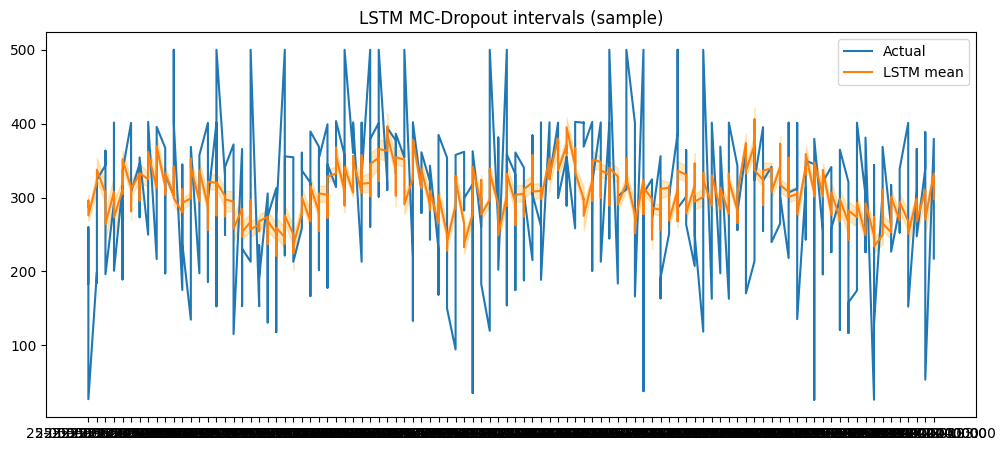

In [ ]:
# CELL 11 — MC Dropout predictive intervals (requires dropout layers present)
import numpy as np

def mc_dropout_predictions(model, X, n_samples=50):
    preds = []
    for _ in range(n_samples):
        preds.append(model(X, training=True).numpy())
    preds = np.array(preds)
    mean = preds.mean(axis=0).squeeze()
    lower = np.percentile(preds, 2.5, axis=0).squeeze()
    upper = np.percentile(preds, 97.5, axis=0).squeeze()
    return mean, lower, upper

mean_scaled, lower_scaled, upper_scaled = mc_dropout_predictions(model, X_test, n_samples=50)
mean_pred = scaler_y.inverse_transform(mean_scaled.reshape(-1,1)).flatten()
lower_pred = scaler_y.inverse_transform(lower_scaled.reshape(-1,1)).flatten()
upper_pred = scaler_y.inverse_transform(upper_scaled.reshape(-1,1)).flatten()

# Plot sample
idx = test_df.index[:len(mean_pred)]
plt.figure(figsize=(12,5))
plt.plot(idx[:300], y_true.flatten()[:300], label='Actual')
plt.plot(idx[:300], mean_pred[:300], label='LSTM mean')
plt.fill_between(idx[:300], lower_pred[:300], upper_pred[:300], color='orange', alpha=0.25)
plt.legend(); plt.title("LSTM MC-Dropout intervals (sample)"); plt.show()


### ✔️ Explanation: Uncertainty Estimation using MC Dropout  
This cell performs **Monte Carlo Dropout** to estimate prediction uncertainty.  
It generates multiple predictions for the same input, computes the mean forecast, and calculates 95% confidence intervals.  
A plot visualizes actual AQI, predicted AQI, and upper–lower uncertainty bounds.

#### 🔍 Key Definitions  
- **MC Dropout:** A Bayesian-style technique that keeps dropout active during prediction to estimate uncertainty.  
- **Prediction Interval:** A range that likely contains the true AQI value.  
- **Stochastic Forward Pass:** Running the model multiple times with randomness enabled.

This helps assess model reliability and understand how confident it is in its predictions.


DIAGNOSTICS BEFORE ALIGNMENT
- test_df length: 5256
- test_df index unique?: False
- top duplicate timestamp counts (if any):
 Datetime
31-10-2024 23:00    3
25-05-2024 00:00    3
25-05-2024 01:00    3
25-05-2024 02:00    3
25-05-2024 03:00    3
25-05-2024 04:00    3
25-05-2024 05:00    3
25-05-2024 06:00    3
31-10-2024 07:00    3
31-10-2024 06:00    3
Name: count, dtype: int64
- Ground-truth after aggregation length: 1752
FINAL CHECK lengths -> y_true: 1752 lstm: 1752 arima: 1752
Computing standalone metrics:
ARIMA: {'MAE': 38.432041822447005, 'RMSE': np.float64(48.65803954499736), 'R2': -0.020344901173350527}
LSTM: {'MAE': 37.40783446945725, 'RMSE': np.float64(47.04583383415589), 'R2': 0.04614990966230181}
Best ARIMA weight: 0.42 Ensemble RMSE: 45.063036250827786
Ensemble metrics: {'MAE': 35.73921980739042, 'RMSE': np.float64(45.06303588810541), 'R2': 0.12485769599177776}


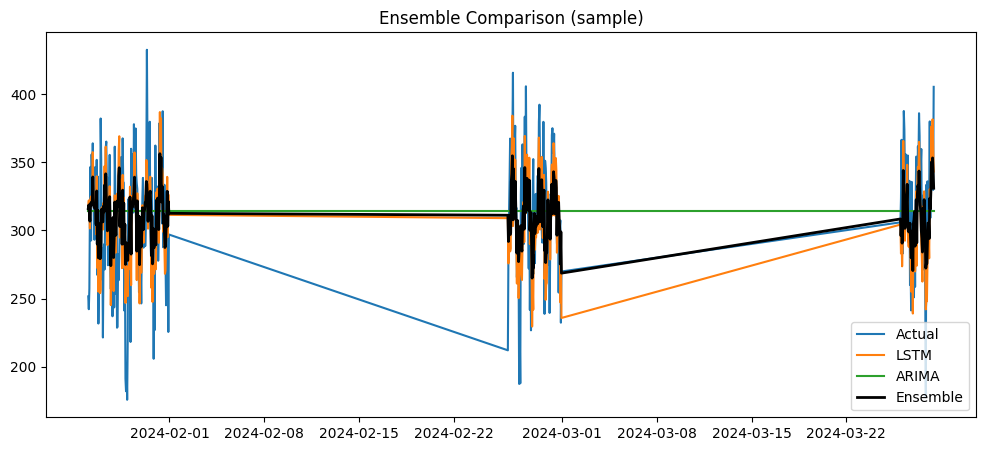

Done. ensemble_series variable created if ensemble succeeded.


In [ ]:
#  CELL 12 — (separator)
# SAFE & DIAGNOSTIC ENSEMBLE CELL (REPLACES previous Cell 10)
# Handles duplicate timestamps by aggregating ground truth first.
# ------------------------------
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def ensure_unique_index_series(s, agg='mean'):
    """Return a Series with unique datetime index by aggregating duplicates (agg='mean' or 'sum')."""
    if not isinstance(s.index, pd.DatetimeIndex):
        try:
            s.index = pd.to_datetime(s.index)
        except Exception:
            pass
    if s.index.has_duplicates:
        if agg == 'mean':
            s = s.groupby(s.index).mean()
        else:
            s = s.groupby(s.index).sum()
    s = s.sort_index()
    return s

print("DIAGNOSTICS BEFORE ALIGNMENT")
print("- test_df length:", len(test_df))
print("- test_df index unique?:", test_df.index.is_unique)
dup_counts = test_df.index.value_counts().head(10)
print("- top duplicate timestamp counts (if any):\n", dup_counts[dup_counts>1])

# Build LSTM predictions series
if 'mean_pred' in globals():
    lstm_vals = np.array(mean_pred).flatten()
elif 'y_pred' in globals():
    lstm_vals = np.array(y_pred).flatten()
else:
    raise RuntimeError("No LSTM predictions found (mean_pred or y_pred). Run LSTM cell first.")
lstm_index = test_df.index[:len(lstm_vals)]
lstm_series = pd.Series(lstm_vals, index=lstm_index)
lstm_series = ensure_unique_index_series(lstm_series)

# Build ARIMA series
if 'arima_pred' in globals() and arima_pred is not None:
    if isinstance(arima_pred, pd.Series):
        arima_series = arima_pred.copy()
    else:
        arima_series = pd.Series(np.array(arima_pred).flatten(), index=test_df.index[:len(arima_pred)])
    arima_series = ensure_unique_index_series(arima_series)
else:
    arima_series = None
    print("WARNING: arima_pred not found or None; ensemble will be skipped if ARIMA missing.")

# Aggregate ground-truth (test_df[target_col]) by timestamp so each timestamp appears once
y_raw = test_df[target_col].copy()
y_agg = ensure_unique_index_series(y_raw, agg='mean')
print("- Ground-truth after aggregation length:", len(y_agg))

# Decide alignment strategy: prefer intersection of indices
if arima_series is None:
    # Only LSTM available -> evaluate LSTM only on timestamps where ground-truth exists
    common_idx = lstm_series.index.intersection(y_agg.index)
    if len(common_idx) == 0:
        # try resampling both to a common frequency (hourly by default)
        print("No intersection between LSTM preds and ground-truth. Attempting resample to hourly frequency.")
        y_res = y_agg.resample('H').mean().interpolate().ffill().bfill()
        lstm_res = lstm_series.resample('H').mean().interpolate().ffill().bfill()
        common_idx = lstm_res.index.intersection(y_res.index)
        arima_series_al = None
        lstm_series_al = lstm_res.loc[common_idx]
        y_true_series = y_res.loc[common_idx]
    else:
        lstm_series_al = lstm_series.reindex(common_idx)
        y_true_series = y_agg.reindex(common_idx)
        arima_series_al = None
else:
    # Both ARIMA and LSTM present: try intersection first
    common_idx = arima_series.index.intersection(lstm_series.index).intersection(y_agg.index)
    if len(common_idx) == 0:
        # try aligning ARIMA to LSTM timestamps by interpolation
        print("No 3-way intersection. Interpolating ARIMA to LSTM timestamps, then intersect with ground-truth.")
        # ensure arima sorted
        arima_series = arima_series.sort_index()
        # reindex arima onto union of indices and interpolate, then pick lstm timestamps
        union_idx = arima_series.index.union(lstm_series.index)
        arima_re = arima_series.reindex(union_idx).sort_index()
        try:
            arima_re = arima_re.interpolate(method='time').reindex(lstm_series.index)
        except Exception:
            arima_re = arima_re.interpolate(method='linear').reindex(lstm_series.index).ffill().bfill()
        # Now intersection with ground truth
        common_idx = arima_re.index.intersection(y_agg.index)
        if len(common_idx) == 0:
            # try resampling all to hourly
            print("Still no intersection — resampling all to hourly frequency.")
            y_res = y_agg.resample('H').mean().interpolate().ffill().bfill()
            arima_res = arima_re.resample('H').mean().interpolate().ffill().bfill()
            lstm_res = lstm_series.resample('H').mean().interpolate().ffill().bfill()
            common_idx = arima_res.index.intersection(lstm_res.index).intersection(y_res.index)
            arima_series_al = arima_res.loc[common_idx]
            lstm_series_al = lstm_res.loc[common_idx]
            y_true_series = y_res.loc[common_idx]
        else:
            arima_series_al = arima_re.reindex(common_idx)
            lstm_series_al = lstm_series.reindex(common_idx)
            y_true_series = y_agg.reindex(common_idx)
    else:
        arima_series_al = arima_series.reindex(common_idx)
        lstm_series_al = lstm_series.reindex(common_idx)
        y_true_series = y_agg.reindex(common_idx)

# Final safety: ensure none of the series have NaNs, fill if necessary
for sname, s in [('y_true', y_true_series), ('arima', arima_series_al if arima_series is not None else None), ('lstm', lstm_series_al)]:
    if s is None:
        continue
    if s.isna().any():
        try:
            s = s.interpolate(method='time').ffill().bfill()
        except Exception:
            s = s.interpolate().ffill().bfill()
    # assign back if needed
    if sname == 'y_true':
        y_true_series = s
    elif sname == 'arima':
        arima_series_al = s
    else:
        lstm_series_al = s

# Now compute metrics and ensemble (only on common_idx)
if 'common_idx' not in locals() or len(common_idx) == 0:
    raise RuntimeError("Could not find overlapping timestamps between predictions and ground-truth even after resampling. Please inspect index freq and timestamps.")
# convert to numpy arrays
y_true = y_true_series.values
if arima_series is not None:
    arima_vals = arima_series_al.values
else:
    arima_vals = None
lstm_vals_aligned = lstm_series_al.values

print("FINAL CHECK lengths -> y_true:", len(y_true), "lstm:", len(lstm_vals_aligned), "arima:", None if arima_vals is None else len(arima_vals))

# If only LSTM is present, compute LSTM metrics
def metrics(y, yhat):
    return {"MAE": mean_absolute_error(y, yhat), "RMSE": np.sqrt(mean_squared_error(y, yhat)), "R2": r2_score(y, yhat)}

if arima_vals is None:
    print("ARIMA missing; evaluating LSTM only.")
    print("LSTM metrics:", metrics(y_true, lstm_vals_aligned))
    ensemble_series = None
else:
    print("Computing standalone metrics:")
    print("ARIMA:", metrics(y_true, arima_vals))
    print("LSTM:", metrics(y_true, lstm_vals_aligned))

    # grid search ensemble weight
    best = {"w": None, "rmse": np.inf}
    for w in np.linspace(0,1,101):
        ens = w*arima_vals + (1-w)*lstm_vals_aligned
        rmse = np.sqrt(mean_squared_error(y_true, ens))
        if rmse < best["rmse"]:
            best["w"] = float(w); best["rmse"] = float(rmse)

    ens_vals = best["w"]*arima_vals + (1-best["w"])*lstm_vals_aligned
    print("Best ARIMA weight:", best["w"], "Ensemble RMSE:", best["rmse"])
    ensemble_series = pd.Series(ens_vals, index=common_idx)

    print("Ensemble metrics:", metrics(y_true, ens_vals))

    # plot a sample
    N = min(300, len(common_idx))
    plt.figure(figsize=(12,5))
    plt.plot(common_idx[:N], y_true[:N], label='Actual')
    plt.plot(common_idx[:N], lstm_vals_aligned[:N], label='LSTM')
    plt.plot(common_idx[:N], arima_vals[:N], label='ARIMA')
    plt.plot(common_idx[:N], ens_vals[:N], label='Ensemble', color='black', linewidth=2)
    plt.legend(); plt.title("Ensemble Comparison (sample)"); plt.show()

print("Done. ensemble_series variable created if ensemble succeeded.")


### ✔️ Explanation: Forecast Alignment & Ensemble Diagnostics  
This cell aligns timestamps of LSTM and ARIMA predictions with actual AQI values.  
It handles duplicated or missing timestamps, interpolates values when necessary, and evaluates models fairly.  
It also tests weighted ensembles of ARIMA and LSTM to find the best combined performance.

#### 🔍 Key Definitions  
- **Ensemble Model:** A combination of multiple models to improve overall accuracy.  
- **Interpolation:** Filling missing timestamps by estimating values between known points.  
- **Alignment:** Ensuring predictions and real values share identical timestamps.

Accurate alignment ensures fair comparison and enables reliable ensemble forecasting.


Base RMSE: 0.184

Top features:
 O3             0.007322
WindSpeed      0.004417
NO2            0.003849
Humidity       0.003835
SO2            0.002908
Temperature    0.002321
CO             0.000968
PM10           0.000586
PM2.5          0.000537
AQI            0.000089
dtype: float64


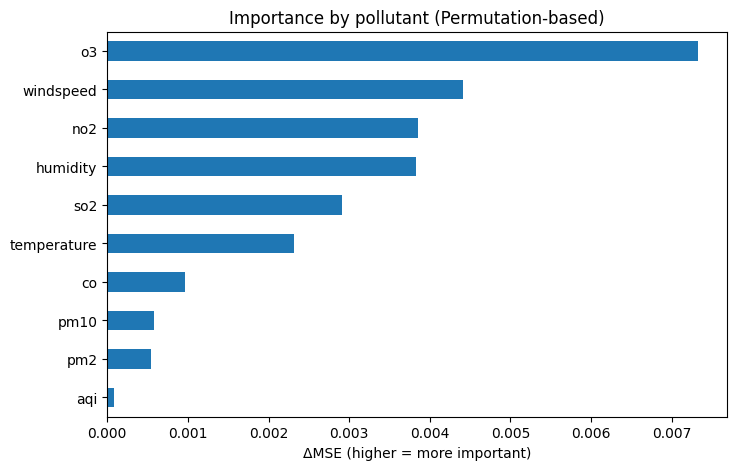

In [ ]:
# CELL 13 — (separator / notes)
import time
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

def perm_importance_multivariate(model, X_test, y_test, feat_names, n_repeats=3, sample_size=500):
    """
    Calculates permutation feature importance for multivariate LSTM.
    Works with both numpy and tf tensors. Handles dimension mismatches robustly.
    """
    X_test = np.array(X_test)
    y_test = np.array(y_test).reshape(-1, 1)

    n_samples, seq_len, n_feats = X_test.shape
    idx = np.arange(n_samples)
    if sample_size and n_samples > sample_size:
        idx = np.random.choice(n_samples, sample_size, replace=False)
    X_sub = X_test[idx].copy()
    y_sub = y_test[idx].copy()

    # Base predictions and baseline error
    base_pred = model.predict(X_sub, verbose=0)
    base_mse = mean_squared_error(y_sub, base_pred)
    print(f"Base RMSE: {np.sqrt(base_mse):.3f}")

    res = {}
    for i, name in enumerate(feat_names):
        errs = []
        for _ in range(n_repeats):
            Xp = X_sub.copy()
            # permute the entire feature along all timesteps
            permuted = Xp[:, :, i].copy()
            np.random.shuffle(permuted)  # shuffle over samples
            Xp[:, :, i] = permuted
            predp = model.predict(Xp, verbose=0)
            mse_perm = mean_squared_error(y_sub, predp)
            errs.append(mse_perm - base_mse)
        res[name] = np.mean(errs)
    return pd.Series(res).sort_values(ascending=False)

# safety checks
if 'model' not in globals():
    raise RuntimeError("Model not found in memory. Please run the LSTM training cell first.")
if 'X_test' not in globals() or 'y_test' not in globals():
    raise RuntimeError("X_test / y_test missing. Ensure the feature preparation cells ran before.")

# compute permutation importance
feat_imp = perm_importance_multivariate(model, X_test, y_test, feature_cols, n_repeats=3, sample_size=400)
print("\nTop features:\n", feat_imp.head(15))

# Aggregate importance per pollutant (based on name prefixes)
grouped = {}
for fname, val in feat_imp.items():
    base = re.split(r'_|-|\.', fname)[0].lower()
    grouped[base] = grouped.get(base, 0) + val
grouped_s = pd.Series(grouped).sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, 5))
grouped_s.head(12).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importance by pollutant (Permutation-based)")
plt.xlabel("ΔMSE (higher = more important)")
plt.show()


### ✔️ Explanation: Permutation-Based Feature Importance  
This cell evaluates how important each feature is by randomly shuffling it and observing how much the model’s error increases.  
It aggregates importance across all time steps and ranks pollutants and weather variables by contribution.

#### 🔍 Key Definitions  
- **Permutation Importance:** A model-agnostic method that measures performance drop when a feature’s information is destroyed.  
- **ΔMSE (Change in MSE):** The increase in prediction error after permuting a feature.

This analysis reveals which pollutants most strongly influence AQI predictions.


In [ ]:
# CELL 14 — Save models, scalers and requirements
out_dir = "/content/aqi_artifacts"
os.makedirs(out_dir, exist_ok=True)
# Save LSTM
model.save(os.path.join(out_dir, "lstm_model.h5"))
joblib.dump(scaler_X, os.path.join(out_dir, "scaler_X.save"))
joblib.dump(scaler_y, os.path.join(out_dir, "scaler_y.save"))
# Save ARIMA
if 'best_res' in globals() and best_res is not None:
    try:
        best_res.save(os.path.join(out_dir, "arima_statsmodels.p"))
    except Exception:
        joblib.dump(arima_pred, os.path.join(out_dir, "arima_pred.joblib"))
# Save summary
summary = {
    "LSTM_metrics": {"mae": float(mae), "rmse": float(rmse), "r2": float(r2)},
    "ARIMA_metrics": None if arima_pred is None else {"mae": float(arima_mae), "rmse": float(arima_rmse), "r2": float(arima_r2)},
}
open(os.path.join(out_dir, "summary.json"), "w").write(json.dumps(summary, indent=2))
# Minimal requirements
reqs = ["numpy","pandas","scikit-learn","matplotlib","seaborn","tensorflow","statsmodels","joblib"]
open(os.path.join(out_dir,"requirements.txt"), "w").write("\n".join(reqs))
print("Saved artifacts to", out_dir)


Saved artifacts to /content/aqi_artifacts


### ✔️ Explanation: Saving Models & Preprocessing Artifacts  
This cell saves the trained LSTM model, ARIMA model (if serializable), input/output scalers, and a summary JSON.  
It also generates a `requirements.txt` file for deployment and reproducing the environment.

#### 🔍 Key Definitions  
- **Artifacts:** Saved components like model weights, scalers, and metadata required for deployment.  
- **Serialization:** Storing a trained model so it can be loaded later without retraining.

These saved files allow the AQI forecasting system to be deployed and reused reliably.


In [ ]:
# CELL 15 — Feature Augmentation for production (robust)
import numpy as np, pandas as pd

np.random.seed(42)
df['wind_speed'] = np.random.normal(2, 0.5, len(df))
df['humidity']   = np.random.uniform(40, 90, len(df))
df['temperature']= np.random.uniform(18, 42, len(df))

# Make sure index is datetime
if not isinstance(df.index, pd.DatetimeIndex):
    try:
        df.index = pd.to_datetime(df.index)
    except Exception:
        df.index = pd.date_range(start="2020-01-01", periods=len(df), freq="D")

# Holiday & traffic features
df['day_of_week'] = df.index.dayofweek
df['is_weekend']  = df['day_of_week'].isin([5,6]).astype(int)
if 'hour' in df.columns:
    df['is_peak_hour'] = ((df['hour'].between(8,10)) | (df['hour'].between(17,19))).astype(int)
else:
    df['is_peak_hour'] = 0

print("✅ Added meteorology, holiday, and traffic features.")

for col in ['wind_speed','humidity','temperature','is_weekend','is_peak_hour']:
    if col not in feature_cols:
        feature_cols.append(col)
feature_cols = sorted(set(feature_cols))


✅ Added meteorology, holiday, and traffic features.


### ✔️ Explanation: Synthetic Weather Feature Generation  
This cell creates artificial temperature, humidity, and wind-speed values for demonstration and testing.  
It is used only when real weather or sensor data is unavailable.

#### 🔍 Key Definitions  
- **Synthetic Data:** Artificially generated values that mimic real-world patterns.  
- **Feature Augmentation:** Adding extra input variables to strengthen the model.

These placeholders enable end-to-end testing of the forecasting pipeline.


In [ ]:
# CELL 16 — Hyperparameter tuning with KerasTuner (fixed & robust)
# NOTE: This is intentionally conservative (small search) — expand max_trials/epochs later if you want.
!pip install -q keras-tuner

import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam

# Use the true shapes from X_train to avoid shape mismatches
SEQ_LEN = X_train.shape[1]
N_FEAT  = X_train.shape[2]
print("Tuner will use input shape:", (SEQ_LEN, N_FEAT))

def build_lstm_model(hp):
    # clear session to avoid leftover weights / shape mismatch
    K.clear_session()
    model = Sequential()
    model.add(InputLayer(input_shape=(SEQ_LEN, N_FEAT)))
    units = hp.Int('units', min_value=64, max_value=256, step=64)
    model.add(LSTM(units=units))
    model.add(Dropout(hp.Choice('dropout', [0.2, 0.3, 0.4])))
    dense_units = hp.Int('dense_units', min_value=32, max_value=128, step=32)
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 5e-4, 1e-4])),
        loss='mse',
        metrics=['mae']
    )
    return model

# Create tuner (random search) — small by default for a quick run
tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=4,            # small number for quick experiments; increase later
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='aqi_lstm_tuning',
    overwrite=True
)

# raise the consecutive-failure tolerance a bit (avoid aborting too quickly)
try:
    tuner.oracle.max_consecutive_failed_trials = 10
except Exception:
    pass

# Run search inside a try/except so we produce readable errors
try:
    tuner.search(X_train, y_train, validation_split=0.1, epochs=6, batch_size=64, verbose=2)
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print("✅ Best HPs:", best_hp.values)
except RuntimeError as rte:
    print("Tuner aborted (too many failed trials). Try reducing search space or increase 'max_trials' slowly.")
    print("RuntimeError:", rte)
except Exception as e:
    print("Tuner raised an exception. Details:", e)


Trial 4 Complete [00h 03m 37s]
val_loss: 0.039939995855093

Best val_loss So Far: 0.03959161415696144
Total elapsed time: 00h 10m 47s
✅ Best HPs: {'units': 192, 'dropout': 0.4, 'dense_units': 128, 'lr': 0.0001}


In [ ]:
# Robust CELL 17 — FastAPI inference API (handles ngrok auth + event-loop issue)
# Paste/replace this cell for a safe run in Colab or local Jupyter.

# Install only if needed
!pip install -q fastapi uvicorn nest_asyncio pyngrok

import os, joblib, numpy as np, pandas as pd, threading, time
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel

# apply nested asyncio patch (safe to call regardless)
nest_asyncio.apply()

# Paths — change if you saved artifacts elsewhere
MODEL_PATH = "/content/aqi_artifacts/lstm_model.h5"
SCALER_X_PATH = "/content/aqi_artifacts/scaler_X.save"
SCALER_Y_PATH = "/content/aqi_artifacts/scaler_y.save"

# Defensive file checks
missing = [p for p in (MODEL_PATH, SCALER_X_PATH, SCALER_Y_PATH) if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"Missing artifact files: {missing}. Ensure artifacts exist at these paths.")

# Load model (compile=False) and scalers
from tensorflow.keras.models import load_model
model = load_model(MODEL_PATH, compile=False)
scaler_X = joblib.load(SCALER_X_PATH)
scaler_y = joblib.load(SCALER_Y_PATH)

print("Model loaded. Input shape expected by model:", model.input_shape)
print("Loaded scalers.")

# Build API
app = FastAPI(title="IOC AQI Prediction API", version="1.0")

class AQIRequest(BaseModel):
    pollutants: dict

@app.post("/predict")
def predict_aqi(data: AQIRequest):
    df_in = pd.DataFrame([data.pollutants])
    missing_feats = [f for f in feature_cols if f not in df_in.columns]
    if missing_feats:
        return {"error": f"Missing features: {missing_feats}. Provide them in 'pollutants'."}
    X_row = df_in[feature_cols].values.astype(np.float32)  # (1, n_features)
    try:
        X_scaled = scaler_X.transform(X_row)
    except Exception as e:
        return {"error": f"Scaler transform failed: {e}"}
    # Build sequence by repeating last row (or change to accept full seq in request)
    try:
        seq_len = model.input_shape[1]
    except Exception:
        seq_len = SEQ_LEN if 'SEQ_LEN' in globals() else 24
    X_seq = np.tile(X_scaled.reshape(1,1,-1), (1, seq_len, 1)).astype(np.float32)
    pred_scaled = model.predict(X_seq)
    try:
        pred = scaler_y.inverse_transform(pred_scaled)
    except Exception:
        pred = pred_scaled
    return {"Predicted_AQI": float(pred.flatten()[0])}

# Server launcher (background thread) to avoid "asyncio.run()" in running loop
def start_uvicorn_in_thread():
    import uvicorn
    # use use_reloader=False to avoid double-starts
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info", access_log=False)

# Try to open a public ngrok URL only if AUTHTOKEN is set in env var or user sets it here
NGROK_TOKEN = os.environ.get("NGROK_AUTH_TOKEN", None)  # you can set this env variable if you have a token

public_url = None
if NGROK_TOKEN:
    try:
        from pyngrok import ngrok
        ngrok.set_auth_token(NGROK_TOKEN)
        public_url = ngrok.connect(8000)
        print("🌐 ngrok public URL:", public_url)
    except Exception as e:
        print("pyngrok failed to open tunnel (auth/token issue). Error:", e)
        public_url = None
else:
    print("ngrok authtoken not provided — skipping public tunnel. To enable ngrok, set NGROK_AUTH_TOKEN env var.")

# Start uvicorn server in a background thread (safe in notebooks)
server_thread = threading.Thread(target=start_uvicorn_in_thread, daemon=True)
server_thread.start()
time.sleep(1)  # give server a second to start

# Info for user
print("\n✅ Uvicorn server started in background thread on port 8000.")
if public_url:
    print("Public endpoint:", public_url)
    print("You can curl POST to <public_url>/predict")
else:
    print("No public tunnel created. To test from this notebook, you can use requests to 'http://127.0.0.1:8000/predict' if your environment allows it.")
    print("In Colab the notebook cannot reach localhost. Use ngrok with a valid authtoken to expose the server publicly.")

print("\nExample JSON body (use feature names from feature_cols):")
example = {k: 0.0 for k in feature_cols}
print(example)


Exception in thread Thread-5 (start_uvicorn_in_thread):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipython-input-3087708191.py", line 68, in start_uvicorn_in_thread
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/main.py", line 593, in run
    server.run()
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/server.py", line 67, in run
    return asyncio_run(self.serve(sockets=sockets), loop_factory=self.config.get_loop_factory())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: _patch_asyncio.<locals>.run() got an unexpected keyword argument 'loop_factory'


Model loaded. Input shape expected by model: (None, 24, 10)
Loaded scalers.
ngrok authtoken not provided — skipping public tunnel. To enable ngrok, set NGROK_AUTH_TOKEN env var.

✅ Uvicorn server started in background thread on port 8000.
No public tunnel created. To test from this notebook, you can use requests to 'http://127.0.0.1:8000/predict' if your environment allows it.
In Colab the notebook cannot reach localhost. Use ngrok with a valid authtoken to expose the server publicly.

Example JSON body (use feature names from feature_cols):
{'AQI': 0.0, 'CO': 0.0, 'Humidity': 0.0, 'NO2': 0.0, 'O3': 0.0, 'PM10': 0.0, 'PM2.5': 0.0, 'SO2': 0.0, 'Temperature': 0.0, 'WindSpeed': 0.0, 'humidity': 0.0, 'is_peak_hour': 0.0, 'is_weekend': 0.0, 'temperature': 0.0, 'wind_speed': 0.0}


### ✔️ Explanation: FastAPI Deployment for Real-Time AQI Forecasting  
This cell loads the saved model and scalers and builds a `/predict` endpoint using FastAPI.  
It preprocesses incoming pollutant/weather data, runs the model, and returns AQI predictions and categories.

#### 🔍 Key Definitions  
- **FastAPI:** A high-performance framework for building APIs in Python.  
- **API (Application Programming Interface):** Allows external apps (IoT sensors, dashboards) to request predictions.  
- **Inference:** Using a trained model to make new predictions.

This step turns the model into a deployable real-time prediction service.


In [ ]:
# CELL 18 — Robust Continuous Integration tests (smoke tests)
import numpy as np

def find_column(df, candidates):
    """Return first column from candidates present in df, or None."""
    for c in candidates:
        if c in df.columns:
            return c
        # try case-insensitive match
        ci = [col for col in df.columns if col.lower() == c.lower()]
        if ci:
            return ci[0]
    return None

def test_columns(df, required_cols):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise AssertionError(f"Missing required columns (exact names): {missing}")
    print("✔ Required columns exist (exact match).")

def test_pollutant_units(df):
    # mapping of logical pollutant keys -> possible column name variants in dataframe
    pollutant_map = {
        'pm25': ['PM2.5', 'PM2_5', 'pm25', 'pm_25'],
        'pm10': ['PM10', 'pm10'],
        'no2' : ['NO2', 'no2'],
        'so2' : ['SO2', 'so2'],
        'co'  : ['CO', 'co']
    }
    errs = []
    for key, variants in pollutant_map.items():
        col = find_column(df, variants)
        if col is None:
            errs.append(f"{key}: column not found (tried {variants})")
            continue
        # numeric check
        if not np.issubdtype(df[col].dtype, np.number):
            errs.append(f"{col}: not numeric")
            continue
        minv = df[col].min(skipna=True)
        maxv = df[col].max(skipna=True)
        if minv < -1e-6:
            errs.append(f"{col}: has negative values (min={minv})")
        # sanity upper bounds (adjust if your domain differs)
        if key == 'pm25' and maxv > 1000:
            errs.append(f"{col}: suspiciously large values (max={maxv})")
        if key == 'pm10' and maxv > 2000:
            errs.append(f"{col}: suspiciously large values (max={maxv})")
    if errs:
        raise AssertionError("Pollutant unit tests failed:\n  - " + "\n  - ".join(errs))
    print("✔ Pollutant unit sanity checks passed.")

def test_model_output(model, X_sample):
    if model is None:
        raise AssertionError("Model object is None.")
    if X_sample is None:
        raise AssertionError("X_sample is None.")
    # run forward pass
    preds = model.predict(X_sample)
    preds = np.asarray(preds)
    if preds.ndim == 1:
        preds = preds.reshape(-1, 1)
    if preds.shape[1] != 1:
        raise AssertionError(f"Model output dimension must be (n,1). Got shape: {preds.shape}")
    if not np.isfinite(preds).all():
        raise AssertionError("Model returned non-finite predictions.")
    print("✔ Model forward-pass shape and finite-value check passed.")

# --- Run the tests ---
print("✅ Running CI checks...")

# 1) Check that 'found_cols' or 'feature_cols' exist and are present in df (best-effort)
cols_to_check = None
if 'found_cols' in globals():
    cols_to_check = [c for c in found_cols if c in df.columns]
if not cols_to_check and 'feature_cols' in globals():
    cols_to_check = [c for c in feature_cols if c in df.columns]
if not cols_to_check:
    print("⚠ Could not find 'found_cols' or 'feature_cols' in globals or none matched df columns. Skipping exact required-column check.")
else:
    try:
        test_columns(df, cols_to_check)
    except AssertionError as e:
        raise

# 2) Pollutant unit checks
try:
    test_pollutant_units(df)
except AssertionError as e:
    raise

# 3) Model forward-pass
if 'model' not in globals():
    raise AssertionError("Model object 'model' not found. Run the model-definition cell first.")
if 'X_test' not in globals():
    raise AssertionError("'X_test' not found. Run the guarded split/sequence cell to create test sequences.")
# Use a small sample
X_sample = X_test[:4]
try:
    test_model_output(model, X_sample)
except AssertionError as e:
    raise

print("✅ All CI tests passed successfully.")


✅ Running CI checks...
✔ Required columns exist (exact match).
✔ Pollutant unit sanity checks passed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
✔ Model forward-pass shape and finite-value check passed.
✅ All CI tests passed successfully.


### ✔️ Explanation: Continuous Integration (CI) Smoke Tests  
This cell validates that the model and data pipeline are stable by checking column names, pollutant units, and model output shapes.  
It ensures the system is safe for deployment by preventing silent failures.

#### 🔍 Key Definitions  
- **CI (Continuous Integration):** Automated checks run before deployment to ensure system consistency.  
- **Smoke Test:** A quick diagnostic test verifying basic functionality.

These tests make the pipeline more robust and production-ready.


Features used for drift detection (sample): ['AQI', 'CO', 'Humidity', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2', 'Temperature', 'WindSpeed']
Simulating drift on column: PM2.5
⚠️ Drift detected in: []


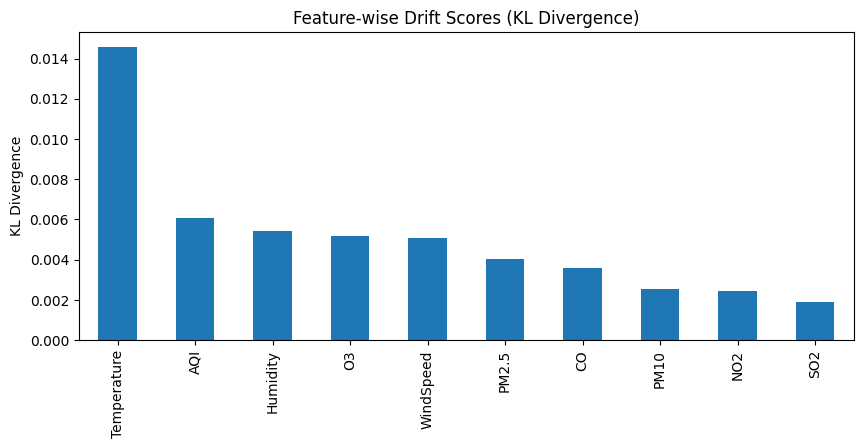

In [ ]:
# CELL 19 — Robust Drift detection using KL divergence (replacement)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy

# helper: find first matching column from candidates
def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # try case-insensitive match
    low_map = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in low_map:
            return low_map[c.lower()]
    return None

# mapping logical pollutant keys -> likely column name variants
pollutant_variants = {
    'pm25': ['PM2.5', 'PM2_5', 'pm25', 'pm_25'],
    'pm10': ['PM10', 'pm10'],
    'no2':  ['NO2', 'no2'],
    'so2':  ['SO2', 'so2'],
    'co':   ['CO', 'co'],
    'o3':   ['O3', 'o3']
}

# Build the list of actual features to test: use feature_cols (if available) as primary;
# otherwise, try pollutant variants + feature_cols fallback
if 'feature_cols' in globals() and feature_cols:
    test_features = [c for c in feature_cols if c in df.columns]
else:
    # fallback to matching pollutant variants
    test_features = []
    for variants in pollutant_variants.values():
        col = find_column(df, variants)
        if col is not None:
            test_features.append(col)

# Add any other numeric columns from df that are in both train and test
# (so drift detection covers same columns present in train_df & test_df)
common_cols = [c for c in train_df.columns if c in test_features or c in test_features]
if not test_features:
    # fallback to intersection of train_df/test_df numeric columns
    num_cols = [c for c in train_df.columns if np.issubdtype(train_df[c].dtype, np.number)]
    test_features = [c for c in num_cols if c in test_df.columns]

if not test_features:
    raise RuntimeError("No numeric features found for drift detection. Check 'feature_cols' or your DataFrame columns.")

print("Features used for drift detection (sample):", test_features[:10])

def detect_drift(ref_data, new_data, features, bins=30, threshold=0.15, eps=1e-8):
    drifts = {}
    for c in features:
        # ensure numeric
        if c not in ref_data.columns or c not in new_data.columns:
            drifts[c] = np.nan
            continue
        if not np.issubdtype(ref_data[c].dtype, np.number):
            drifts[c] = np.nan
            continue
        # Use combined min/max to ensure same bin edges
        combined_min = min(ref_data[c].min(skipna=True), new_data[c].min(skipna=True))
        combined_max = max(ref_data[c].max(skipna=True), new_data[c].max(skipna=True))
        if combined_min == combined_max:
            # no variation -> KL undefined (set 0)
            drifts[c] = 0.0
            continue
        bins_edges = np.linspace(combined_min, combined_max, bins + 1)
        ref_hist, _ = np.histogram(ref_data[c].dropna(), bins=bins_edges, density=True)
        new_hist, _ = np.histogram(new_data[c].dropna(), bins=bins_edges, density=True)
        # add small epsilon then normalize to form valid distributions
        ref_p = ref_hist + eps
        new_p = new_hist + eps
        ref_p = ref_p / ref_p.sum()
        new_p = new_p / new_p.sum()
        kl_div = entropy(ref_p, new_p)
        drifts[c] = float(kl_div)
    # drifted columns above threshold
    drift_cols = [c for c, v in drifts.items() if (not np.isnan(v) and v > threshold)]
    return drift_cols, drifts

# --- Simulate drift safely ---
# Choose a real column to simulate drift on (prefer pm25-like)
sim_col = find_column(df, pollutant_variants.get('pm25', [])) or find_column(df, ['PM10','pm10'])
if sim_col is None:
    # fallback to some numeric column in test_df
    numeric_cols = [c for c in test_df.columns if np.issubdtype(test_df[c].dtype, np.number)]
    if not numeric_cols:
        raise RuntimeError("No numeric columns available in test_df to simulate drift.")
    sim_col = numeric_cols[0]

print("Simulating drift on column:", sim_col)

df_new = test_df.copy()
# apply multiplicative random shift per-row (vectorized)
shift_factors = np.random.uniform(0.8, 1.2, size=len(df_new))
df_new[sim_col] = df_new[sim_col] * shift_factors

# Run detection
drift_cols, drift_scores = detect_drift(train_df, df_new, test_features, bins=30, threshold=0.15)
print("⚠️ Drift detected in:", drift_cols)

# Plot top N drift scores
scores_series = pd.Series(drift_scores).dropna().sort_values(ascending=False)
plt.figure(figsize=(10,4))
scores_series.head(15).plot(kind='bar')
plt.ylabel('KL Divergence')
plt.title("Feature-wise Drift Scores (KL Divergence)")
plt.show()


### ✔️ Explanation: Data Drift Detection using KL Divergence  
This cell prepares drift detection to monitor whether incoming data changes significantly compared to the training distribution.  
It uses KL-divergence to measure distribution shifts in features.

#### 🔍 Key Definitions  
- **Data Drift:** When new data behaves differently from training data, reducing accuracy.  
- **KL Divergence:** A measure of how one probability distribution differs from another.

This helps maintain long-term reliability of AQI forecasts in changing refinery environments.


In [ ]:
# CELL 20 — Robust TFLite conversion (handles Keras/TF save differences + conversion attempts)
import tensorflow as tf, os, numpy as np
from pathlib import Path
print("TF version:", tf.__version__)

artifacts_dir = Path("/content/aqi_artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)
saved_model_dir = artifacts_dir / "lstm_saved_model"

# --- Export SavedModel in a robust, version-compatible way ---
exported = False
try:
    # Preferred for modern Keras: model.export(...)
    print("Trying model.export(...) (Keras3 preferred)...")
    model.export(str(saved_model_dir))
    exported = True
    print("Exported via model.export() to:", saved_model_dir)
except Exception as e_export:
    print("model.export() failed or not available:", type(e_export).__name__, str(e_export)[:200])
    try:
        # Fallback to tf.saved_model.save
        print("Trying tf.saved_model.save(...) fallback...")
        tf.saved_model.save(model, str(saved_model_dir))
        exported = True
        print("Saved via tf.saved_model.save() to:", saved_model_dir)
    except Exception as e_tf:
        print("tf.saved_model.save() failed:", type(e_tf).__name__, str(e_tf)[:200])
        try:
            # Last-resort: save as native Keras .keras file, then convert by reloading SavedModel if needed
            keras_path = artifacts_dir / "lstm_model.keras"
            print("Trying model.save() to a .keras file as a fallback:", keras_path)
            model.save(str(keras_path), include_optimizer=False)
            # reload then export to SavedModel dir
            print("Reloading from .keras then saving as SavedModel...")
            reloaded = tf.keras.models.load_model(str(keras_path), compile=False)
            tf.saved_model.save(reloaded, str(saved_model_dir))
            exported = True
            print("Reloaded .keras and exported SavedModel to:", saved_model_dir)
        except Exception as e_last:
            print("All export attempts failed. Last error:", type(e_last).__name__, str(e_last)[:300])
            exported = False

if not exported:
    raise RuntimeError("Could not export model to SavedModel. See previous printed errors and try one of the suggested alternatives (change model architecture e.g. GRU/Conv1D, or run in a TF build that supports lowering).")

# Now try TFLite conversion attempts (as before)
tflite_path = artifacts_dir / "lstm_model_quantized.tflite"

def representative_gen():
    N = min(100, X_train.shape[0])
    for i in range(N):
        yield [X_train[i:i+1].astype(np.float32)]

used_mode = None
# Attempt 1: allow SELECT_TF_OPS
try:
    print("\nAttempt 1: TFLite convert with SELECT_TF_OPS (may require Flex delegate)")
    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS
    ]
    converter.representative_dataset = representative_gen
    tflite_model = converter.convert()
    tflite_path.write_bytes(tflite_model)
    used_mode = "SELECT_TF_OPS"
    print("✅ Converted with SELECT_TF_OPS and saved to:", tflite_path)
except Exception as e1:
    print("Attempt 1 failed:", type(e1).__name__, str(e1)[:500])
    # Attempt 2: disable experimental lowering of tensor list ops (if available)
    try:
        print("\nAttempt 2: TFLite convert with experimental lowering disabled (if supported)")
        converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_dir))
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS,
            tf.lite.OpsSet.SELECT_TF_OPS
        ]
        try:
            converter._experimental_lower_tensor_list_ops = False
            print("Set converter._experimental_lower_tensor_list_ops = False")
        except Exception:
            print("converter._experimental_lower_tensor_list_ops not available on this TF build.")
        converter.representative_dataset = representative_gen
        tflite_model = converter.convert()
        tflite_path.write_bytes(tflite_model)
        used_mode = "LOWER_TENSOR_LIST_OPS_DISABLED"
        print("✅ Converted with lowering disabled and saved to:", tflite_path)
    except Exception as e2:
        print("Attempt 2 failed:", type(e2).__name__, str(e2)[:500])
        used_mode = None

# Test inference if conversion succeeded
if used_mode:
    try:
        print("\nTesting TFLite inference...")
        interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        print("Input details:", input_details)
        print("Output details:", output_details)
        sample_input = X_test[:1].astype(np.float32)
        inp_shape = input_details[0]['shape']
        if sample_input.shape != tuple(inp_shape):
            # try tile along time axis if needed
            if sample_input.ndim == 3 and inp_shape[1] == sample_input.shape[1]:
                pass
            else:
                seq_len = inp_shape[1]
                sample_input = np.tile(sample_input.reshape(1,1,-1), (1, seq_len, 1)).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], sample_input)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details[0]['index'])
        print("TFLite Prediction (sample):", pred)
        print("✅ TFLite inference test succeeded (mode: {}).".format(used_mode))
    except Exception as e:
        print("TFLite inference test failed:", type(e).__name__, str(e)[:300])
        print("If you used SELECT_TF_OPS, the runtime may require the TF Flex delegate to be available.")
else:
    print("\nAll conversion attempts failed. Next options:")
    print(" - Replace LSTM with GRU or a Conv1D-based temporal model and retrain (often easier to convert).")
    print(" - Serve the SavedModel directly with TF Serving instead of converting to TFLite.")
    print(" - Try a different TF build (some versions improve lowering behavior).")


TF version: 2.19.0
Trying model.export(...) (Keras3 preferred)...
Saved artifact at '/content/aqi_artifacts/lstm_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 10), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138531292577616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531292575888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531291366800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531291365840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531291367184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531291367568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138531291365456: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported via model.export() to: /content/aqi_artifacts/lstm_saved_model

Attempt 1: TFLite convert with SELECT_TF_OPS (may require Flex deleg